In [1]:
#!conda env list

In [2]:
#!conda run -p /home/njm12/ATMS_523/envs/xarray-climate python -m ipykernel install --user --name xarray-climate --display-name "Python (xarray-climate)"

In [3]:
import sys
print(sys.executable)

/home/njm12/ATMS_523/envs/xarray-climate/bin/python


In [4]:
# Cell 1: Imports and environment setup
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

#Interactive Tool Imports
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # or "notebook_connected"

#Statistical Significance Testing Imports
from scipy.stats import kruskal
import itertools

# Allow OGR to accept non-closed rings
os.environ["OGR_GEOMETRY_ACCEPT_UNCLOSED_RING"] = "YES"

# --- Configuration ---
base_dir = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/Land-Water"
target_crs = "EPSG:26915"  # UTM Zone 15
tornado_csv = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times_and_nocturnal_bins.csv"  # Update with your CSV path
states_of_interest = ["IL", "IA", "MO"]
min_date = pd.to_datetime("1950-01-01")  # Start from first date in dataset

In [5]:
# Cell 2: Load UMESC Mississippi River shapefiles
pool_dirs = [f"Pool {p}" for p in range(12, 27) if p != 23] + ["Open River", "Open River 2"]
gdfs = []

for pool_dir in pool_dirs:
    if "Open River" in pool_dir:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z16n83.shp"))
        local_crs = "EPSG:26916"
    else:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z15n83.shp"))
        local_crs = target_crs

    for f in shp_files:
        gdf = gpd.read_file(f)
        if gdf.crs is None:
            gdf = gdf.set_crs(local_crs)
        gdf = gdf.to_crs(target_crs)
        gdf["POOL"] = pool_dir
        gdfs.append(gdf)

umesc_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=target_crs)
print("UMESC combined:", umesc_all.shape)
print(f"Pools included: {sorted(umesc_all['POOL'].unique())}")

ERROR 1: PROJ: proj_create_from_database: Open of /home/njm12/ATMS_523/envs/xarray-climate/share/proj failed


UMESC combined: (8050, 14)
Pools included: ['Open River', 'Open River 2', 'Pool 12', 'Pool 13', 'Pool 14', 'Pool 15', 'Pool 16', 'Pool 17', 'Pool 18', 'Pool 19', 'Pool 20', 'Pool 21', 'Pool 22', 'Pool 24', 'Pool 25', 'Pool 26']


In [6]:
# --- Derive approximate river centerline from UMESC polygons ---
# Fix invalid polygons before union
umesc_all["geometry"] = umesc_all.geometry.make_valid()
umesc_all["geometry"] = umesc_all.buffer(0)  # Ensures clean geometry

# Use the new 'union_all()' method (replaces deprecated unary_union)
river_union = umesc_all.union_all()

# Derive approximate river centerline
river_centerline = gpd.GeoSeries([river_union], crs=target_crs).buffer(-200).boundary
river_centerline = gpd.GeoDataFrame(geometry=river_centerline, crs=target_crs)
print("River centerline constructed from UMESC polygons.")

River centerline constructed from UMESC polygons.


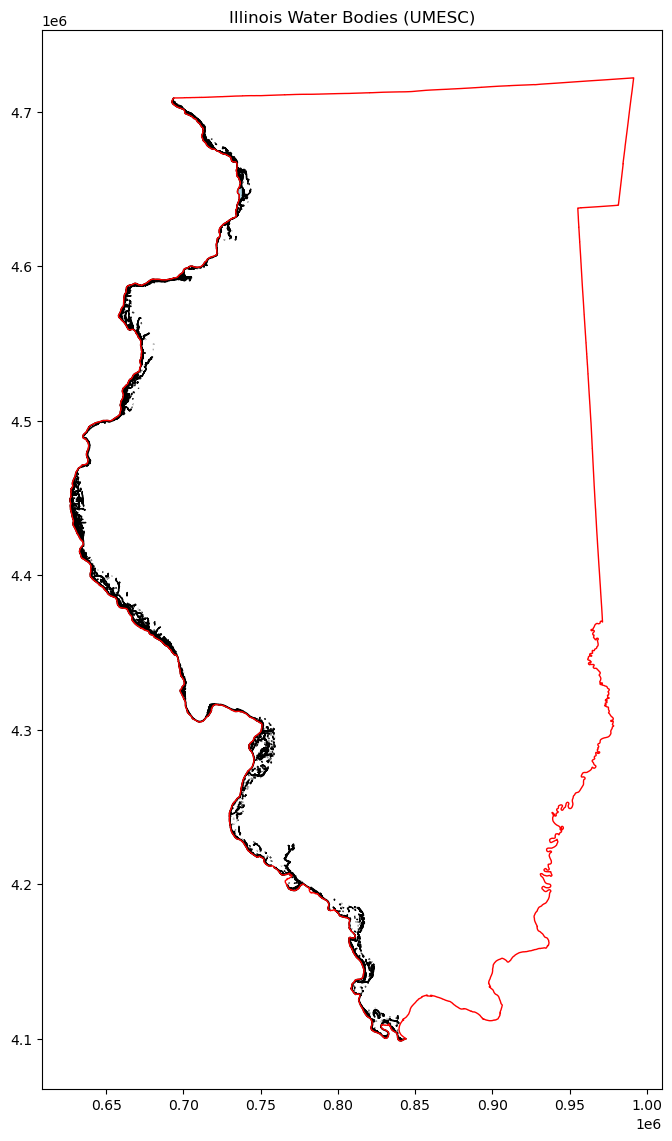

In [7]:
# Cell 3: Extract Illinois water portion
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(url)
illinois = states[states["NAME"] == "Illinois"].to_crs(target_crs)

# Filter water polygons only
water_only = umesc_all[umesc_all["LAND_WATER"] == "Water"].copy()
water_il = gpd.clip(water_only, illinois)

# Plot check
ax = water_il.plot(figsize=(8, 14), color="lightblue", edgecolor="k")
illinois.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Illinois Water Bodies (UMESC)")
plt.show()

In [8]:
print("Number of invalid geometries in water_only:", (~water_only.is_valid).sum())
print("Invalid geometries indices:", water_only[~water_only.is_valid].index)

Number of invalid geometries in water_only: 0
Invalid geometries indices: Index([], dtype='int64')


In [9]:
# Fix invalid geometries using buffer(0) - only if needed
water_only.loc[~water_only.is_valid, "geometry"] = water_only.loc[~water_only.is_valid, "geometry"].buffer(0)

# Verify
print("Invalid geometries after fix:", (~water_only.is_valid).sum())

Invalid geometries after fix: 0


In [10]:
# Ensure Illinois geometry is valid
illinois["geometry"] = illinois["geometry"].buffer(0)

# Perform clip
water_il = gpd.clip(water_only, illinois)

print("Clipped water shapes:", water_il.shape)

Clipped water shapes: (2876, 14)


In [11]:
# Combine all Illinois water polygons into a single geometry
river_il = water_il.union_all()
print(type(river_il))
print("Bounds of Illinois river section:", river_il.bounds)

<class 'shapely.geometry.multipolygon.MultiPolygon'>
Bounds of Illinois river section: (626594.3664122473, 4098437.22724262, 844182.0029604747, 4708927.272888837)


In [12]:
# Automatic date parsing
tornadoes = pd.read_csv(tornado_csv, parse_dates=['date'])

# Filter by states, pre-F/F/EF-scale, and date (can include stronger tornadoes on map, if necessary / min_date will likely be changed)
tornadoes = tornadoes[
    tornadoes['st'].isin(states_of_interest) &
    tornadoes['mag'].isin([0, 1, 2, 3, 4, 5]) &
    (tornadoes['date'] >= min_date)
]

print("Filtered tornadoes:", tornadoes.shape)
tornadoes

Filtered tornadoes: (8287, 42)


,om,yr,mo,dy,date,time,tz,st,stf,stn,...,day_night_bin,night_subtype,diurnal_sec,nocturnal_sec,diurnal_hours,nocturnal_hours,evening_end,next_sunrise,morning_start,core_night_hours
0,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,Day,Day,34627.299453,51772.700547,9.618694,14.381306,1950-12-02 19:38:03.787114-06:00,1950-12-03 07:00:56.487661-06:00,1950-12-03 04:00:56.487661-06:00,8.381306
1,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,Day,Day,34699.430474,51700.569526,9.638731,14.361269,1950-12-02 19:37:08.674669-06:00,1950-12-03 06:58:49.244195-06:00,1950-12-03 03:58:49.244195-06:00,8.361269
2,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,Night,Evening Transition,34887.029542,51512.970458,9.690842,14.309158,1950-12-02 19:39:09.003928-06:00,1950-12-03 06:57:41.974386-06:00,1950-12-03 03:57:41.974386-06:00,8.309158
3,5,1950,1,25,1950-01-25,19:30:00,3,MO,29,2,...,Night,Evening Transition,36361.039170,50038.960830,10.100289,13.899711,1950-01-25 20:18:20.206660-06:00,1950-01-26 07:12:19.167490-06:00,1950-01-26 04:12:19.167490-06:00,7.899711
4,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,Night,Core Night,35364.024167,51035.975833,9.823340,14.176660,1950-01-25 19:56:38.836911-06:00,1950-01-26 07:07:14.812744-06:00,1950-01-26 04:07:14.812744-06:00,8.176660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8282,624857,2024,8,15,2024-08-15,22:06:00,3,IL,17,0,...,Night,Evening Transition,49613.421441,36786.578559,13.781506,10.218494,2024-08-15 22:57:22.068989-05:00,2024-08-16 06:10:28.647548-05:00,2024-08-16 03:10:28.647548-05:00,4.218494
8283,624880,2024,8,30,2024-08-30,11:45:00,3,IL,17,0,...,Day,Day,46939.435932,39460.564068,13.038732,10.961268,2024-08-30 22:30:38.696436-05:00,2024-08-31 06:28:19.260504-05:00,2024-08-31 03:28:19.260504-05:00,4.961268
8284,624820,2024,8,5,2024-08-05,20:57:00,3,IA,19,0,...,Night,Evening Transition,51664.904335,34735.095665,14.351362,9.648638,2024-08-05 23:23:41.746723-05:00,2024-08-06 06:02:36.842388-05:00,2024-08-06 03:02:36.842388-05:00,3.648638
8285,624821,2024,8,5,2024-08-05,21:11:00,3,IA,19,0,...,Night,Evening Transition,51664.363072,34735.636928,14.351212,9.648788,2024-08-05 23:23:11.960360-05:00,2024-08-06 06:02:07.597288-05:00,2024-08-06 03:02:07.597288-05:00,3.648788


In [13]:
print("Columns in dataset:")
print(tornadoes.columns)

print("\nPreliminary Day/Night counts:")
print(tornadoes["day_night_bin"].value_counts())

Columns in dataset:
Index(['om', 'yr', 'mo', 'dy', 'date', 'time', 'tz', 'st', 'stf', 'stn', 'mag',
       'inj', 'fat', 'loss', 'closs', 'slat', 'slon', 'elat', 'elon', 'len',
       'wid', 'ns', 'sn', 'sg', 'f1', 'f2', 'f3', 'f4', 'fc', 'datetime',
       'sunrise_local', 'sunset_local', 'day_night_bin', 'night_subtype',
       'diurnal_sec', 'nocturnal_sec', 'diurnal_hours', 'nocturnal_hours',
       'evening_end', 'next_sunrise', 'morning_start', 'core_night_hours'],
      dtype='object')

Preliminary Day/Night counts:
day_night_bin
Day      6155
Night    2132
Name: count, dtype: int64


In [14]:
# Remove any rows with missing or invalid coordinates
coord_cols = ['slon', 'slat', 'elon', 'elat']
tornadoes = tornadoes.dropna(subset=coord_cols)

# Remove out-of-bounds or unrealistic coordinates
tornadoes = tornadoes[
    (tornadoes['slon'].between(-180, 180)) &
    (tornadoes['elon'].between(-180, 180)) &
    (tornadoes['slat'].between(-90, 90)) &
    (tornadoes['elat'].between(-90, 90))
]
print("After coordinate cleaning:", tornadoes.shape)

After coordinate cleaning: (8287, 42)


In [15]:
# --- Fix 1: Convert positive longitudes (U.S. longitudes are negative west of Greenwich) ---
tornadoes['slon'] = tornadoes['slon'].apply(lambda x: -x if x > 0 else x)
tornadoes['elon'] = tornadoes['elon'].apply(lambda x: -x if x > 0 else x)

# --- Fix 2: Remove zero or missing coordinates (invalid positions) ---
tornadoes.loc[tornadoes['slat'] == 0, 'slat'] = np.nan
tornadoes.loc[tornadoes['elat'] == 0, 'elat'] = np.nan
tornadoes.loc[tornadoes['slon'] == 0, 'slon'] = np.nan
tornadoes.loc[tornadoes['elon'] == 0, 'elon'] = np.nan

# Drop rows with NaNs after cleaning
tornadoes = tornadoes.dropna(subset=['slon', 'slat', 'elon', 'elat']).copy()

# Check coordinate ranges again
print("Longitude range (fixed):", tornadoes[['slon', 'elon']].min().min(), "to", tornadoes[['slon', 'elon']].max().max())
print("Latitude range (fixed):", tornadoes[['slat', 'elat']].min().min(), "to", tornadoes[['slat', 'elat']].max().max())

Longitude range (fixed): -96.6 to -85.23
Latitude range (fixed): 36.0022 to 45.5


In [16]:
from shapely.geometry import LineString, Point
import geopandas as gpd

# Create LineString or Point geometries
def make_geom(row):
    if pd.isna(row['elon']) or pd.isna(row['elat']) or \
       (row['elon'] == row['slon'] and row['elat'] == row['slat']):
        return Point(row['slon'], row['slat'])
    else:
        return LineString([(row['slon'], row['slat']), (row['elon'], row['elat'])])

tornadoes['geometry'] = tornadoes.apply(make_geom, axis=1)

# Convert to GeoDataFrame
tornado_gdf = gpd.GeoDataFrame(tornadoes, geometry='geometry', crs="EPSG:4326")

# Reproject to match water shapefile CRS
tornado_gdf = tornado_gdf.to_crs(target_crs)

print("Tornado geometries rebuilt")
print("Geometry types:", tornado_gdf.geometry.geom_type.value_counts())
print("Bounds:", tornado_gdf.total_bounds)

Tornado geometries rebuilt
Geometry types: LineString    4739
Point         1054
Name: count, dtype: int64
Bounds: [ 205367.62901075 3987738.95756939 1160467.39964418 5041734.47457036]


In [17]:
# Fix invalid water polygons
water_il['geometry'] = water_il['geometry'].buffer(0)

# Merge into single geometry
river_il_geom = water_il.geometry.union_all()  # or .union_all() if using new shapely

# Ensure the final geometry is valid
from shapely.validation import make_valid
river_il_geom = make_valid(river_il_geom)

In [18]:
# Buffer by 10 km
river_buffer = river_il_geom.buffer(10000)  # adjust as needed

# Check intersections with buffer
tornado_gdf['crosses_river'] = tornado_gdf.intersects(river_buffer)
crossings = tornado_gdf[tornado_gdf['crosses_river']]

print("Total tornadoes crossing Mississippi River or intersecting buffered zone:", crossings.shape[0])
print("Counts by pre-F/F/EF-scale:\n", crossings['mag'].value_counts())

Total tornadoes crossing Mississippi River or intersecting buffered zone: 372
Counts by pre-F/F/EF-scale:
 mag
0    124
1    122
2     79
3     37
4     10
Name: count, dtype: int64


In [19]:
#Quick sanity check to make sure the river buffer is actually or approximately ~10 km (and in the right units). 

from shapely.ops import nearest_points

# Pick a point on the river geometry
river_point = river_il_geom.representative_point()

# Pick nearest point on the buffer boundary
buffer_boundary = river_buffer.boundary
nearest = nearest_points(river_point, buffer_boundary)[1]

# Compute distance in meters (UTM units)
distance_m = river_point.distance(nearest)
distance_km = distance_m / 1000
print(f"Distance from river to buffer boundary: {distance_km:.2f} km")

Distance from river to buffer boundary: 10.67 km


In [20]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # --- Step 5: Plot ---
# fig, ax = plt.subplots(figsize=(10, 14))

# # Plot Illinois water and river buffer
# water_il.plot(ax=ax, color='lightblue', edgecolor='k')
# gpd.GeoSeries([river_buffer]).boundary.plot(ax=ax, color='red', linewidth=2, label='10 km Buffer')

# # Plot all tornadoes (lines + points)
# tornado_gdf.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3)
# tornado_gdf[tornado_gdf.geometry.geom_type == 'Point'].plot(ax=ax, color='gray', markersize=15, alpha=0.4)

# # Plot crossing tornadoes (lines + points)
# crossings.plot(ax=ax, color='blue', linewidth=1.5)
# crossings[crossings.geometry.geom_type == 'Point'].plot(ax=ax, color='blue', markersize=25)

# # Plot Illinois, Missouri, and Iowa boundaries
# illinois.boundary.plot(ax=ax, color='black', linewidth=1, label='Illinois Boundary')

# states_path = "/home/njm12/ATMS_596/ne_10m_admin_1_states_provinces.shp"
# states = gpd.read_file(states_path).to_crs(target_crs)
# states_mo_ia = states[states['name'].isin(['Missouri', 'Iowa'])]
# states_mo_ia.boundary.plot(ax=ax, color='lightgray', linewidth=1, label='MO / IA Boundary')

# # --- Custom legend handles (combined line + point) ---
# legend_elements = [
#     Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
#            label='All Tornadoes', alpha=0.6),
#     Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
#            label='Crossing Tornadoes', alpha=0.9),
#     Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
#     Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
#     Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
# ]

# # --- Labels, title, and caption ---
# ax.legend(handles=legend_elements, loc='upper right')
# ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
# ax.set_xlabel("Easting (meters, UTM Zone 15N)", fontsize=11)
# ax.set_ylabel("Northing (meters, UTM Zone 15N)", fontsize=11)

# # Figure caption
# caption = (
#     "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
#     "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
#     "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
#     "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
#     "provide geographic context. Coordinates are shown in UTM Zone 15N (meters)."
# )
# plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

# plt.show()

In [21]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # Reproject all layers to geographic (EPSG:4326)
# tornado_geo = tornado_gdf.to_crs("EPSG:4326")
# crossings_geo = crossings.to_crs("EPSG:4326")
# water_il_geo = water_il.to_crs("EPSG:4326")
# illinois_geo = illinois.to_crs("EPSG:4326")
# river_buffer_geo = gpd.GeoSeries([river_buffer], crs=water_il.crs).to_crs("EPSG:4326")

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(10, 14), subplot_kw={'projection': ccrs.PlateCarree()})

# # Add map background
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
# ax.add_feature(cfeature.STATES, edgecolor='lightgray', linewidth=0.6)

# # Plot layers
# water_il_geo.plot(ax=ax, color='lightblue', edgecolor='k', transform=ccrs.PlateCarree(), zorder=1)
# river_buffer_geo.boundary.plot(ax=ax, color='red', linewidth=1.5, transform=ccrs.PlateCarree(), label='10 km Buffer', zorder=2)
# tornado_geo.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3, transform=ccrs.PlateCarree(), label='All Tornadoes', zorder=3)
# crossings_geo.plot(ax=ax, color='blue', linewidth=1.5, transform=ccrs.PlateCarree(), label='Crossing Tornadoes', zorder=4)
# illinois_geo.boundary.plot(ax=ax, color='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

# # Gridlines and coordinate labels
# gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {'size': 11}
# gl.ylabel_style = {'size': 11}

# # Add axis labels manually
# ax.text(0.5, -0.06, 'Longitude (°W)', va='center', ha='center', fontsize=12, transform=ax.transAxes)
# ax.text(-0.08, 0.5, 'Latitude (°N)', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)

# # --- Custom legend handles (combined line + point) ---
# legend_elements = [
#     Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
#            label='All Tornadoes', alpha=0.6),
#     Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
#            label='Crossing Tornadoes', alpha=0.9),
#     Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
#     Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
#     Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
# ]

# # Add title and legend
# ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
# ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# # Caption
# caption = (
#     "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
#     "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
#     "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
#     "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
#     "provide geographic context. Coordinates are shown in degrees latitude and longitude."
# )
# plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()

In [22]:
# -------------------------------------------------------------------
# --- Identify west-side, east-side, and crossing tornadoes ---
# UPDATED: NEAREST-POINT RIVER METHOD
# -------------------------------------------------------------------

from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Start with all tornadoes (EF0–EF5)
# ------------------------------------------------
weak_tornadoes = tornado_gdf[
    tornado_gdf["mag"].isin([0, 1, 2, 3, 4, 5])
].copy()

# ------------------------------------------------
# 2. Tornadoes that physically cross/touch river
# (UNCHANGED)
# ------------------------------------------------
crossing_tornadoes = weak_tornadoes[
    weak_tornadoes.intersects(river_il_geom)
].copy()

# ------------------------------------------------
# 3. Tornadoes within/touching 10 km buffer
# but NOT touching/crossing river
# ------------------------------------------------
buffer_only = weak_tornadoes[
    weak_tornadoes.intersects(river_buffer) &
    (~weak_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 4. Representative point for side determination
# ------------------------------------------------
buffer_only["rep_point"] = (
    buffer_only.geometry.representative_point()
)

# ------------------------------------------------
# 5. Determine west/east relative to
# LOCAL NEAREST RIVER POSITION
# ------------------------------------------------
def assign_side(point_geom):

    # nearest point ON river
    nearest_river_pt = nearest_points(
        point_geom,
        river_il_geom
    )[1]

    # compare relative x-position
    dx = point_geom.x - nearest_river_pt.x

    return "West" if dx < 0 else "East"

# Apply classification
buffer_only["side"] = (
    buffer_only["rep_point"]
    .apply(assign_side)
)

# ------------------------------------------------
# 6. Final west/east groups
# ------------------------------------------------
west_side = buffer_only[
    buffer_only["side"] == "West"
].copy()

east_side = buffer_only[
    buffer_only["side"] == "East"
].copy()

# ------------------------------------------------
# 7. Print summary results
# ------------------------------------------------
print("\n--- Tornado Interaction Summary ---")

print(f"Total tornadoes: {len(weak_tornadoes)}")

print(
    "  • West-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(west_side)}"
)

print(
    "  • East-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(east_side)}"
)

print(
    "  • Crossing/touching the river: "
    f"{len(crossing_tornadoes)}"
)

print(
    "  • Sum check: "
    f"{len(west_side) + len(east_side) + len(crossing_tornadoes)} "
    "(should equal 372)"
)


--- Tornado Interaction Summary ---
Total tornadoes: 5793
  • West-side (within/touching 10 km buffer, not touching river): 142
  • East-side (within/touching 10 km buffer, not touching river): 141
  • Crossing/touching the river: 89
  • Sum check: 372 (should equal 372)


In [23]:
# ---------- Robust classification into West Control / East Control / Test (buffer/river) ----------
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure we use the variable names you have defined earlier:
# tornado_gdf  (all tornadoes, already reprojected to target_crs)
# weak_tornadoes (subset of tornado_gdf with mag in [0,1,2])
# river_il_geom  (shapely geometry of Illinois river section)
# river_buffer   (10 km buffer around river_il_geom) -- can be shapely geometry or GeoSeries

# 0) Ensure consistent CRS on weak_tornadoes
weak_tornadoes = weak_tornadoes.to_crs(target_crs)

# 1) Ensure buffer is a single (unary) shapely geometry for intersections
# If river_buffer is a GeoSeries or GeoDataFrame, get the unary_union (or .iloc[0] if single)
try:
    buffer_union = river_buffer
    # if it's a GeoSeries/GeoDataFrame convert to unary_union
    if hasattr(buffer_union, "unary_union"):
        buffer_union = buffer_union.unary_union
except NameError:
    # If river_buffer not available, create from river_il_geom
    buffer_union = river_il_geom.buffer(10000).union()

In [24]:
# 2) Test population: any weak tornado that intersects/touches the buffer OR intersects the river polygon itself
#    (this includes crossings which intersect the river geometry)
test_mask = weak_tornadoes.geometry.intersects(buffer_union) | weak_tornadoes.geometry.intersects(river_il_geom)
test_population = weak_tornadoes[test_mask].copy()

In [25]:
# 3) Outside buffer: those that do NOT intersect the buffer
# Compute side relative to actual river geometry
outside_buffer = weak_tornadoes[~test_mask].copy()

outside_buffer["centroid"] = outside_buffer.geometry.centroid

def assign_west_east(row, river_geom):
    centroid = row.centroid
    nearest = nearest_points(centroid, river_geom)[1]  # nearest point on river
    dx = centroid.x - nearest.x
    return "West Control" if dx < 0 else "East Control"

outside_buffer["side_type"] = outside_buffer.apply(assign_west_east, axis=1, river_geom=river_il_geom)

# Reassign west_control and east_control
west_control = outside_buffer[outside_buffer["side_type"] == "West Control"].copy()
east_control = outside_buffer[outside_buffer["side_type"] == "East Control"].copy()

#Before: split by centroid_x vs a single river_center_x -> vertical line.
#After: split by relative position to nearest river point -> follows meandering river.

In [26]:
# 7) Verify counts and find any unclassified (should not happen, but check)
combined_idx = test_population.index.union(west_control.index).union(east_control.index)
unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
print("Initial sizes:")
print(f"  Test population (intersect buffer/river): {len(test_population)}")
print(f"  West control (outside buffer):            {len(west_control)}")
print(f"  East control (outside buffer):            {len(east_control)}")
print(f"  Unclassified (should be 0):               {len(unclassified)}")
print(f"  Sum categories:                           {len(test_population)+len(west_control)+len(east_control)}")
print(f"  Total tornadoes:                          {len(weak_tornadoes)}")

Initial sizes:
  Test population (intersect buffer/river): 372
  West control (outside buffer):            3554
  East control (outside buffer):            1867
  Unclassified (should be 0):               0
  Sum categories:                           5793
  Total tornadoes:                          5793


In [27]:
print("\nUpdated Day/Night counts:")
print(tornadoes["day_night_bin"].value_counts())


Updated Day/Night counts:
day_night_bin
Day      4303
Night    1490
Name: count, dtype: int64


In [28]:
# 8) If any unclassified exist (tiny rounding artifacts), assign them deterministically:
if len(unclassified) > 0:
    # compute centroid x for those too
    unclassified["centroid"] = unclassified.geometry.centroid
    unclassified["centroid_x"] = unclassified["centroid"].apply(lambda p: p.x)
    # assign by centroid_x
    assign_west = unclassified[unclassified["centroid_x"] < river_center_x].index
    assign_east = unclassified[unclassified["centroid_x"] >= river_center_x].index
    west_control = pd.concat([west_control, unclassified.loc[assign_west]])
    east_control = pd.concat([east_control, unclassified.loc[assign_east]])
    # recompute combined check
    combined_idx = test_population.index.union(west_control.index).union(east_control.index)
    unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
    print("After deterministic centroid assignment, remaining unclassified:", len(unclassified))
    # If still unclassified (very unlikely), assign by nearest distance to river centerline
    if len(unclassified) > 0:
        # build a river centerline (if you have river_centerline GeoSeries earlier use that)
        try:
            centerline = river_centerline.unary_union
        except Exception:
            # fallback: approximate centerline by taking river_il_geom.representative_point()
            centerline = river_il_geom.representative_point()
        # compute distance to centerline and assign west/east by centroid_x anyway
        for idx, row in unclassified.iterrows():
            cx = row.geometry.centroid.x
            if cx < river_center_x:
                west_control = pd.concat([west_control, row.to_frame().T])
            else:
                east_control = pd.concat([east_control, row.to_frame().T])
        
# final check
combined_idx = test_population.index.union(west_control.index).union(east_control.index)
unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
print("After fallback nearest assignment, remaining unclassified:", len(unclassified))

After fallback nearest assignment, remaining unclassified: 0


In [29]:
# 9) Final assert / sanity check
total_calc = len(test_population) + len(west_control) + len(east_control)
print("\nFinal totals check:")
print(f"  Sum categories = {total_calc}")
print(f"  Total tornadoes = {len(weak_tornadoes)}")
assert total_calc == len(weak_tornadoes), "Final counts DO NOT sum to total tornadoes!"


Final totals check:
  Sum categories = 5793
  Total tornadoes = 5793


In [30]:
# 10) Create breakdown table for EF 0/1/2/3/4/5
def mag_counts(df):
    # Ensure mag is int-like and EF 0/1/2/3/4/5
    s = df["mag"].astype(int).value_counts().reindex([0, 1, 2, 3, 4, 5], fill_value=0)
    return s.to_dict()

summary = pd.DataFrame({
    "Category": ["West Control", "East Control", "Test (Buffer/River)"],
    "Count": [len(west_control), len(east_control), len(test_population)],
    "EF0": [mag_counts(west_control)[0], mag_counts(east_control)[0], mag_counts(test_population)[0]],
    "EF1": [mag_counts(west_control)[1], mag_counts(east_control)[1], mag_counts(test_population)[1]],
    "EF2": [mag_counts(west_control)[2], mag_counts(east_control)[2], mag_counts(test_population)[2]],
    "EF3": [mag_counts(west_control)[3], mag_counts(east_control)[3], mag_counts(test_population)[3]],
    "EF4": [mag_counts(west_control)[4], mag_counts(east_control)[4], mag_counts(test_population)[4]],
    "EF5": [mag_counts(west_control)[5], mag_counts(east_control)[5], mag_counts(test_population)[5]],
})

summary["Total EF0–EF5"] = summary[["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]].sum(axis=1)

# Add totals row
totals = summary[["Count", "EF0", "EF1", "EF2", "EF3", "EF4", "EF5", "Total EF0–EF5"]].sum()
totals_row = pd.DataFrame([["All Tornadoes", totals["Count"], int(totals["EF0"]), int(totals["EF1"]), int(totals["EF2"]), int(totals["EF3"]), int(totals["EF4"]), int(totals["EF5"]), int(totals["Total EF0–EF5"])]],
                          columns=summary.columns)
summary = pd.concat([summary, totals_row], ignore_index=True)

print("\n--- Tornado Populations Summary ---")
print(summary.to_string(index=False))


--- Tornado Populations Summary ---
           Category  Count  EF0  EF1  EF2  EF3  EF4  EF5  Total EF0–EF5
       West Control   3554 1561 1158  588  176   65    6           3554
       East Control   1867  885  628  242   84   26    2           1867
Test (Buffer/River)    372  124  122   79   37   10    0            372
      All Tornadoes   5793 2570 1908  909  297  101    8           5793


In [31]:
# # ================================================================
# # Clustered Bar Chart: pre-F/F/EF-scale Distribution by Category
# # ================================================================

# import numpy as np
# import matplotlib.pyplot as plt

# # Categories (clusters)
# categories = ["West Control", "East Control", "Test (Buffer/River)"]

# # pre-F/F/EF-scale bins
# ef_bins = ["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]

# # Extract counts from summary table
# data = summary.loc[summary["Category"].isin(categories), ef_bins].values

# # Bar configuration
# n_groups = len(categories)
# n_bars = len(ef_bins)
# bar_width = 0.12

# x = np.arange(n_groups)

# # Colors for pre-F/F/EF-scale
# colors = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99", "#e31a1c"]

# plt.figure(figsize=(10,6))

# for i, ef in enumerate(ef_bins):

#     plt.bar(
#         x + i*bar_width,
#         data[:, i],
#         width=bar_width,
#         label=ef,
#         color=colors[i],
#         edgecolor="black"
#     )

#     # Add value labels
#     for j in range(n_groups):
#         count = data[j, i]
#         if count > 0:
#             plt.text(
#                 x[j] + i*bar_width,
#                 count + max(data.flatten())*0.01,
#                 int(count),
#                 ha='center',
#                 fontsize=8
#             )

# # Axis formatting
# plt.xticks(x + bar_width*2.5, categories)
# plt.ylabel("Number of Tornadoes")
# plt.xlabel("Category")
# plt.title("pre-F/F/EF-scale Distribution by Tornado Population")

# plt.legend(title="pre-F/F/EF Scale")

# plt.grid(axis='y', linestyle='--', alpha=0.4)

# plt.tight_layout()
# plt.show()

In [32]:
# # --------------------------------------------------------------
# # Create Day/Night pre-F/F/EF-scale breakdown table
# # --------------------------------------------------------------

# def mag_counts(df):
#     s = df["mag"].astype(int).value_counts().reindex([0,1,2,3,4,5], fill_value=0)
#     return s.to_dict()

# # Assign side_type to full dataset
# weak_tornadoes["side_type"] = "Unclassified"
# weak_tornadoes.loc[weak_tornadoes.index.isin(west_control.index), "side_type"] = "West Control"
# weak_tornadoes.loc[weak_tornadoes.index.isin(east_control.index), "side_type"] = "East Control"
# weak_tornadoes.loc[weak_tornadoes.index.isin(test_population.index), "side_type"] = "Test (Buffer/River)"

# # Keep only classified tornadoes
# df = weak_tornadoes[weak_tornadoes["side_type"] != "Unclassified"].copy()

# rows = []

# categories = ["West Control", "East Control", "Test (Buffer/River)"]
# periods = ["Day", "Night"]

# for cat in categories:
    
#     for period in periods:
        
#         subset = df[
#             (df["side_type"] == cat) &
#             (df["day_night_bin"] == period)
#         ]
        
#         counts = mag_counts(subset)
        
#         rows.append({
#             "Category": cat,
#             "Time": period,
#             "Count": len(subset),
#             "EF0": counts[0],
#             "EF1": counts[1],
#             "EF2": counts[2],
#             "EF3": counts[3],
#             "EF4": counts[4],
#             "EF5": counts[5],
#         })

# summary = pd.DataFrame(rows)

# summary["Total EF0–EF5"] = summary[["EF0","EF1","EF2","EF3","EF4","EF5"]].sum(axis=1)

# # --------------------------------------------------------------
# # Add totals row
# # --------------------------------------------------------------

# totals = summary[["Count","EF0","EF1","EF2","EF3","EF4","EF5","Total EF0–EF5"]].sum()

# totals_row = pd.DataFrame(
#     [["All Tornadoes","Day+Night",
#       totals["Count"],
#       int(totals["EF0"]),
#       int(totals["EF1"]),
#       int(totals["EF2"]),
#       int(totals["EF3"]),
#       int(totals["EF4"]),
#       int(totals["EF5"]),
#       int(totals["Total EF0–EF5"])
#     ]],
#     columns=summary.columns
# )

# summary = pd.concat([summary, totals_row], ignore_index=True)

# print("\n--- Tornado Populations Summary (Day/Night) ---")
# print(summary.to_string(index=False))

In [33]:
# ================================================================
# Assign group labels
# ================================================================

west_side["group"] = "West Side"
east_side["group"] = "East Side"
crossing_tornadoes["group"] = "Crossed River"

# Combine
df_plot = pd.concat([west_side, east_side, crossing_tornadoes], ignore_index=True)

# Convert path length
df_plot["len_km"] = df_plot["len"] * 1.60934

# ================================================================
# Use NEW symmetric bins
# ================================================================

valid_bins = ["Day", "Evening Transition", "Core Night", "Morning Transition"]

df_plot = df_plot[df_plot["night_subtype"].isin(valid_bins)].copy()

# Create combined label
df_plot["group_bin"] = df_plot["group"] + "\n" + df_plot["night_subtype"]

print("\nCounts by group and bin:\n")
print(df_plot.groupby(["group","night_subtype"]).size())


Counts by group and bin:

group          night_subtype     
Crossed River  Core Night             17
               Day                    59
               Evening Transition     11
               Morning Transition      2
East Side      Core Night             15
               Day                   106
               Evening Transition     19
               Morning Transition      1
West Side      Core Night             16
               Day                   104
               Evening Transition     21
               Morning Transition      1
dtype: int64



Counts used in boxplot:

group          night_subtype     
Crossed River  Core Night             17
               Day                    59
               Evening Transition     11
               Morning Transition      2
East Side      Core Night             15
               Day                   106
               Evening Transition     19
               Morning Transition      1
West Side      Core Night             16
               Day                   104
               Evening Transition     21
               Morning Transition      1
dtype: int64


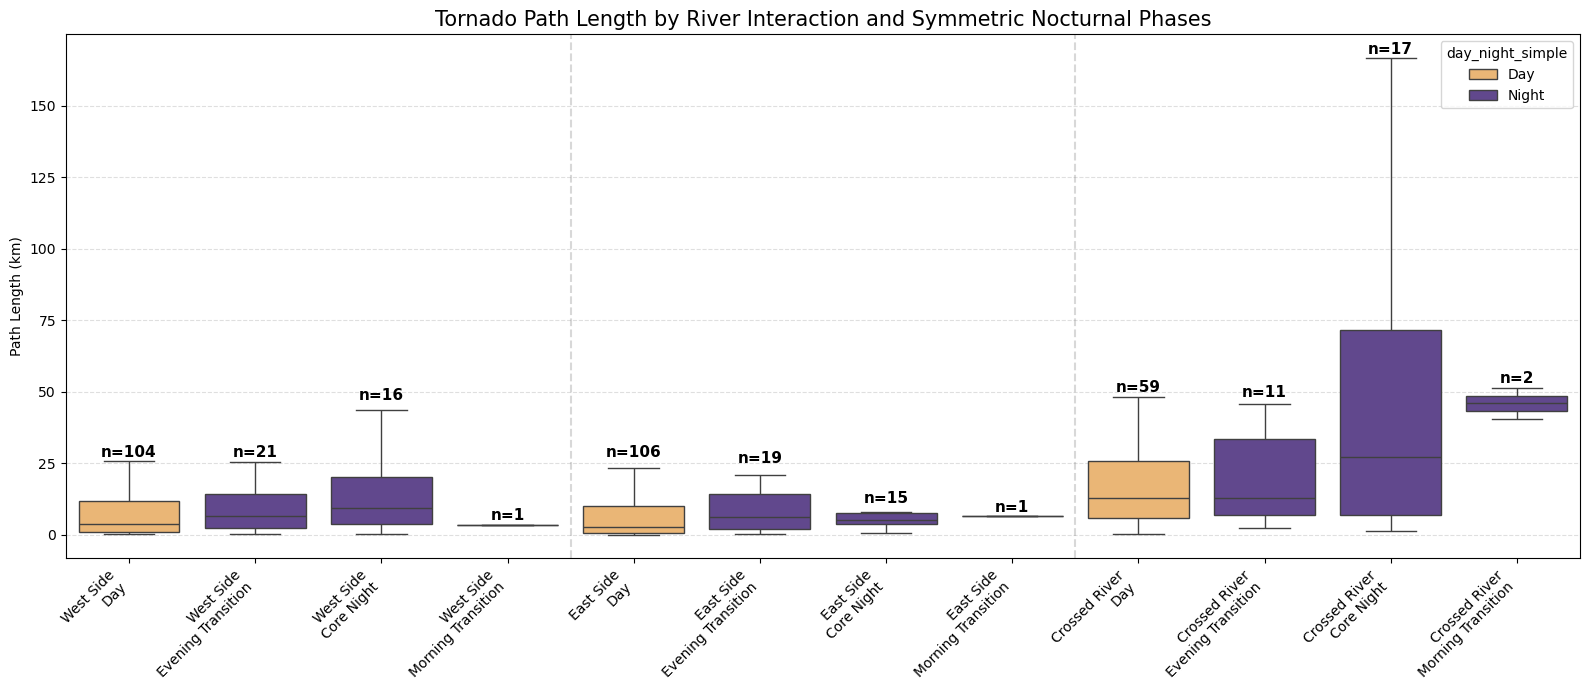

In [37]:
plt.figure(figsize=(16,7))

# Day vs Night color
df_plot["day_night_simple"] = df_plot["night_subtype"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = [
    "West Side\nDay",
    "West Side\nEvening Transition",
    "West Side\nCore Night",
    "West Side\nMorning Transition",

    "East Side\nDay",
    "East Side\nEvening Transition",
    "East Side\nCore Night",
    "East Side\nMorning Transition",

    "Crossed River\nDay",
    "Crossed River\nEvening Transition",
    "Crossed River\nCore Night",
    "Crossed River\nMorning Transition"
]

ax = sns.boxplot(
    data=df_plot,
    x="group_bin",
    y="len_km",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

ax.set_title("Tornado Path Length by River Interaction and Symmetric Nocturnal Phases", fontsize=15)
ax.set_ylabel("Path Length (km)")
ax.set_xlabel("")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=45, ha="right")

for x in [3.5, 7.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

counts = df_plot.groupby(["group","night_subtype"]).size()

print("\nCounts used in boxplot:\n")
print(counts)

# Update positions to match NEW bins
positions = {

    # WEST SIDE
    ("West Side","Day"):(0,27),
    ("West Side","Evening Transition"):(1,27),
    ("West Side","Core Night"):(2,47),
    ("West Side","Morning Transition"):(3,5),

    # EAST SIDE
    ("East Side","Day"):(4,27),
    ("East Side","Evening Transition"):(5,25),
    ("East Side","Core Night"):(6,11),
    ("East Side","Morning Transition"):(7,8),

    # CROSSED RIVER
    ("Crossed River","Day"):(8,50),
    ("Crossed River","Evening Transition"):(9,48),
    ("Crossed River","Core Night"):(10,168),
    ("Crossed River","Morning Transition"):(11,53),
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(x, y, f"n={n}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [38]:
df_plot["group_bin_full"] = df_plot["group"] + " " + df_plot["night_subtype"]

groups = df_plot.groupby("group_bin_full")["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['Crossed River Core Night', 'Crossed River Day', 'Crossed River Evening Transition', 'Crossed River Morning Transition', 'East Side Core Night', 'East Side Day', 'East Side Evening Transition', 'East Side Morning Transition', 'West Side Core Night', 'West Side Day', 'West Side Evening Transition', 'West Side Morning Transition']


In [39]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Path Lengths
------------------------------------------------------
H = 51.568
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [40]:
pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River Core Night,Crossed River Day,1.713183,0.190573,No
1,Crossed River Core Night,Crossed River Evening Transition,0.639673,0.423829,No
2,Crossed River Core Night,Crossed River Morning Transition,0.864706,0.352425,No
3,Crossed River Core Night,East Side Core Night,5.933708,0.014854,Yes
4,Crossed River Core Night,East Side Day,15.498196,0.000083,Yes
...,...,...,...,...,...
61,West Side Core Night,West Side Evening Transition,0.564479,0.452461,No
62,West Side Core Night,West Side Morning Transition,0.666667,0.414216,No
63,West Side Day,West Side Evening Transition,0.737202,0.390559,No
64,West Side Day,West Side Morning Transition,0.004356,0.947377,No


In [41]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River Core Night,Crossed River Day,1.713183,0.190573,No,12.577810,No
1,Crossed River Core Night,Crossed River Evening Transition,0.639673,0.423829,No,27.972718,No
2,Crossed River Core Night,Crossed River Morning Transition,0.864706,0.352425,No,23.260058,No
3,Crossed River Core Night,East Side Core Night,5.933708,0.014854,Yes,0.980361,No
4,Crossed River Core Night,East Side Day,15.498196,0.000083,Yes,0.005451,Yes
...,...,...,...,...,...,...,...
61,West Side Core Night,West Side Evening Transition,0.564479,0.452461,No,29.862431,No
62,West Side Core Night,West Side Morning Transition,0.666667,0.414216,No,27.338268,No
63,West Side Day,West Side Evening Transition,0.737202,0.390559,No,25.776881,No
64,West Side Day,West Side Morning Transition,0.004356,0.947377,No,62.526878,No


In [42]:
# ================================================================
# Extract significant comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Significant?"] == "Yes"].copy()

print("All significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

# ================================================================
# Bonferroni-significant only
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

#Just a side note: If the study is highly exploratory, the Bonferroni correction may be too conservative and increase Type II errors (missing real differences).

All significant comparisons:


,Group1,Group2,H,p-value
3,Crossed River Core Night,East Side Core Night,5.933708,0.014854
4,Crossed River Core Night,East Side Day,15.498196,0.000083
5,Crossed River Core Night,East Side Evening Transition,5.573006,0.018239
8,Crossed River Core Night,West Side Day,14.503272,0.000140
9,Crossed River Core Night,West Side Evening Transition,6.676615,0.009769
13,Crossed River Day,East Side Core Night,5.601010,0.017950
14,Crossed River Day,East Side Day,23.599712,0.000001
15,Crossed River Day,East Side Evening Transition,4.009427,0.045247
18,Crossed River Day,West Side Day,21.035299,0.000005
19,Crossed River Day,West Side Evening Transition,4.712019,0.029952


Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
4,Crossed River Core Night,East Side Day,15.498196,0.000083,0.005451
8,Crossed River Core Night,West Side Day,14.503272,0.000140,0.009234
14,Crossed River Day,East Side Day,23.599712,0.000001,0.000078
18,Crossed River Day,West Side Day,21.035299,0.000005,0.000298


### Tornado Path Lengths by Symmetric Nocturnal Subtypes (Within Buffer Zone)

A Kruskal–Wallis test was conducted to evaluate differences in tornado path lengths across **11 groups**, representing Crossed River, West Side, and East Side tornadoes subdivided into **Day, Evening Transition, Core Night, and Morning Transition** periods.

The test indicated a statistically significant difference among groups:

- **H = 51.568**  
- **p < 0.001**

This suggests that at least one group exhibits significantly different path length characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests revealed numerous statistically significant differences at the **α = 0.05 level**, particularly involving Crossed River tornadoes:

- **Crossed River Core Night vs East Side Day**  
  (H = 15.50, p < 0.001)

- **Crossed River Core Night vs West Side Day**  
  (H = 14.50, p < 0.001)

- **Crossed River Day vs East Side Day**  
  (H = 23.60, p < 0.001)

- **Crossed River Day vs West Side Day**  
  (H = 21.04, p < 0.001)

- **Crossed River Evening Transition vs East Side Day**  
  (H = 8.55, p = 0.0035)

- **Crossed River Evening Transition vs West Side Day**  
  (H = 7.22, p = 0.0072)

After applying a **Bonferroni correction**, several comparisons remained statistically significant:

- **Crossed River Core Night vs East Side Day**  
  (adj. p = 0.0055)

- **Crossed River Core Night vs West Side Day**  
  (adj. p = 0.0092)

- **Crossed River Day vs East Side Day**  
  (adj. p < 0.001)

- **Crossed River Day vs West Side Day**  
  (adj. p < 0.001)

### Interpretation

These results indicate that **Crossed River tornadoes**, particularly during **daytime and core nocturnal periods**, tend to have significantly longer path lengths compared to **both East Side and West Side daytime tornadoes**.

The strongest and most statistically robust differences consistently involve:

- **Crossed River daytime tornadoes**, and  
- **Crossed River Core Night tornadoes**

relative to **daytime tornadoes on both sides of the river corridor**.

Additional nominally significant comparisons suggest that:
- **Crossed River Evening Transition tornadoes** also tend to exhibit enhanced path lengths relative to East Side and West Side daytime populations
- **Crossed River Morning Transition tornadoes** may exhibit elevated path lengths relative to several East Side and West Side populations, though these signals are weaker and do not survive Bonferroni correction
- Comparisons confined solely within West Side or East Side populations generally remain weak or non-significant

Importantly, within-group comparisons among Crossed River nocturnal subtypes (e.g., Core Night vs Evening Transition or Morning Transition) were generally non-significant. This suggests that the dominant signal is associated more strongly with **river interaction itself** than with finer-scale nocturnal timing differences.

Overall, these findings provide strong evidence that **interaction with the Mississippi River corridor enhances tornado path length**, with the most robust signals emerging for **Crossed River daytime and core nocturnal tornadoes** when compared against daytime tornado populations on either side of the river.

In [43]:
# ================================================================
# Assign group labels
# ================================================================

west_side["group"] = "West Side"
east_side["group"] = "East Side"
crossing_tornadoes["group"] = "Crossed River"

# Combine
df_plot = pd.concat(
    [west_side, east_side, crossing_tornadoes],
    ignore_index=True
)

# ================================================================
# Convert tornado width from yards -> meters
# ================================================================

df_plot["wid_m"] = df_plot["wid"] * 0.9144

# ================================================================
# Use NEW symmetric bins
# ================================================================

valid_bins = [
    "Day",
    "Evening Transition",
    "Core Night",
    "Morning Transition"
]

df_plot = df_plot[
    df_plot["night_subtype"].isin(valid_bins)
].copy()

# ================================================================
# Create combined label
# ================================================================

df_plot["group_bin"] = (
    df_plot["group"] + "\n" + df_plot["night_subtype"]
)

print("\nCounts by group and bin:\n")

print(
    df_plot.groupby(["group","night_subtype"]).size()
)



Counts by group and bin:

group          night_subtype     
Crossed River  Core Night             17
               Day                    59
               Evening Transition     11
               Morning Transition      2
East Side      Core Night             15
               Day                   106
               Evening Transition     19
               Morning Transition      1
West Side      Core Night             16
               Day                   104
               Evening Transition     21
               Morning Transition      1
dtype: int64



Counts used in boxplot:

group          night_subtype     
Crossed River  Core Night             17
               Day                    59
               Evening Transition     11
               Morning Transition      2
East Side      Core Night             15
               Day                   106
               Evening Transition     19
               Morning Transition      1
West Side      Core Night             16
               Day                   104
               Evening Transition     21
               Morning Transition      1
dtype: int64


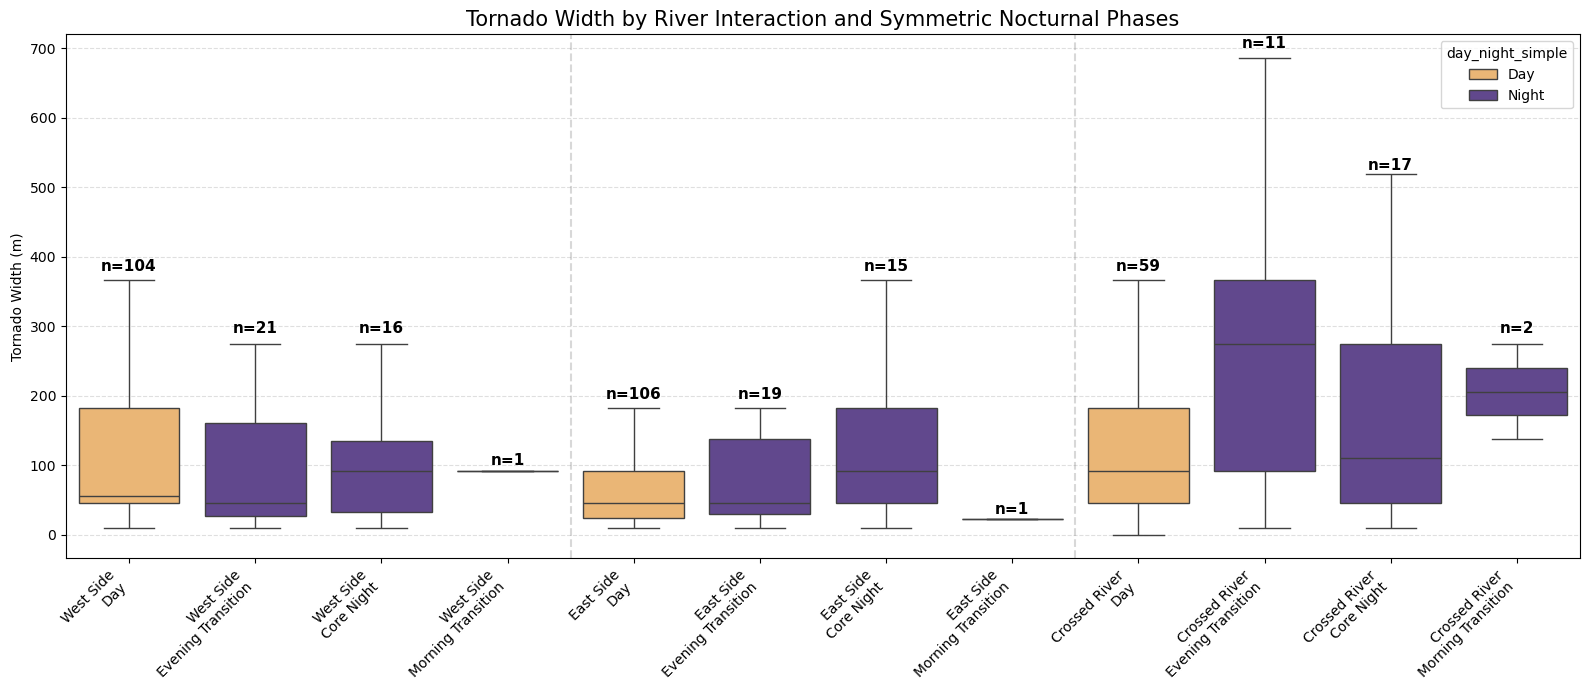

In [50]:
# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(16,7))

# ------------------------------------------------
# Day vs Night color
# ------------------------------------------------

df_plot["day_night_simple"] = df_plot["night_subtype"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

order = [

    "West Side\nDay",
    "West Side\nEvening Transition",
    "West Side\nCore Night",
    "West Side\nMorning Transition",

    "East Side\nDay",
    "East Side\nEvening Transition",
    "East Side\nCore Night",
    "East Side\nMorning Transition",

    "Crossed River\nDay",
    "Crossed River\nEvening Transition",
    "Crossed River\nCore Night",
    "Crossed River\nMorning Transition"
]

ax = sns.boxplot(
    data=df_plot,
    x="group_bin",
    y="wid_m",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Width by River Interaction and Symmetric Nocturnal Phases",
    fontsize=15
)

ax.set_ylabel("Tornado Width (m)")
ax.set_xlabel("")

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=45, ha="right")

# ------------------------------------------------
# Vertical separators
# ------------------------------------------------

for x in [3.5, 7.5]:
    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

# ================================================================
# Counts
# ================================================================

counts = df_plot.groupby(
    ["group","night_subtype"]
).size()

print("\nCounts used in boxplot:\n")
print(counts)

# ================================================================
# Manual count label positions
# (adjust y-values if needed)
# ================================================================

positions = {

    # WEST SIDE
    ("West Side","Day"):(0,380),
    ("West Side","Evening Transition"):(1,290),
    ("West Side","Core Night"):(2,290),
    ("West Side","Morning Transition"):(3,100),

    # EAST SIDE
    ("East Side","Day"):(4,195),
    ("East Side","Evening Transition"):(5,195),
    ("East Side","Core Night"):(6,380),
    ("East Side","Morning Transition"):(7,30),

    # CROSSED RIVER
    ("Crossed River","Day"):(8,380),
    ("Crossed River","Evening Transition"):(9,700),
    ("Crossed River","Core Night"):(10,525),
    ("Crossed River","Morning Transition"):(11,290),
}

for (grp, period), (x, y) in positions.items():

    n = counts.get((grp, period), 0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [51]:
# ================================================================
# Prepare groups for statistical testing
# ================================================================

df_plot["group_bin_full"] = (
    df_plot["group"] + " " + df_plot["night_subtype"]
)

groups = df_plot.groupby(
    "group_bin_full"
)["wid_m"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['Crossed River Core Night', 'Crossed River Day', 'Crossed River Evening Transition', 'Crossed River Morning Transition', 'East Side Core Night', 'East Side Day', 'East Side Evening Transition', 'East Side Morning Transition', 'West Side Core Night', 'West Side Day', 'West Side Evening Transition', 'West Side Morning Transition']


In [52]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal
import itertools

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Widths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print(
        "Interpretation: At least one group differs significantly."
    )
else:
    print(
        "Interpretation: No statistically significant differences detected."
    )



Kruskal-Wallis Test on Tornado Widths
------------------------------------------------------
H = 35.997
p-value = 0.000169
Interpretation: At least one group differs significantly.


In [53]:
# ================================================================
# Pairwise comparisons
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)



Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River Core Night,Crossed River Day,0.392328,0.531078,No
1,Crossed River Core Night,Crossed River Evening Transition,1.183526,0.276639,No
2,Crossed River Core Night,Crossed River Morning Transition,0.284852,0.593539,No
3,Crossed River Core Night,East Side Core Night,0.700728,0.402539,No
4,Crossed River Core Night,East Side Day,7.527510,0.006076,Yes
...,...,...,...,...,...
61,West Side Core Night,West Side Evening Transition,0.028789,0.865268,No
62,West Side Core Night,West Side Morning Transition,0.042821,0.836062,No
63,West Side Day,West Side Evening Transition,1.094141,0.295555,No
64,West Side Day,West Side Morning Transition,0.146761,0.701650,No


In [54]:
# ================================================================
# Bonferroni correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = (
    pairwise_df["p-value"] * n_tests
)

pairwise_df["Adj Significant?"] = (
    pairwise_df["Adj p-value (Bonferroni)"]
    .apply(lambda x: "Yes" if x < 0.05 else "No")
)

print(
    "\nPairwise Kruskal-Wallis results with Bonferroni correction:"
)

display(pairwise_df)



Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River Core Night,Crossed River Day,0.392328,0.531078,No,35.051160,No
1,Crossed River Core Night,Crossed River Evening Transition,1.183526,0.276639,No,18.258200,No
2,Crossed River Core Night,Crossed River Morning Transition,0.284852,0.593539,No,39.173559,No
3,Crossed River Core Night,East Side Core Night,0.700728,0.402539,No,26.567596,No
4,Crossed River Core Night,East Side Day,7.527510,0.006076,Yes,0.401041,No
...,...,...,...,...,...,...,...
61,West Side Core Night,West Side Evening Transition,0.028789,0.865268,No,57.107666,No
62,West Side Core Night,West Side Morning Transition,0.042821,0.836062,No,55.180118,No
63,West Side Day,West Side Evening Transition,1.094141,0.295555,No,19.506661,No
64,West Side Day,West Side Morning Transition,0.146761,0.701650,No,46.308893,No


In [55]:
# ================================================================
# Extract significant comparisons
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Significant?"] == "Yes"
].copy()

print("All significant comparisons:")

display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

# ================================================================
# Bonferroni-significant only
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Adj Significant?"] == "Yes"
].copy()

print("Bonferroni-significant comparisons:")

display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

# NOTE:
# If the study is highly exploratory, the Bonferroni correction
# may be overly conservative and increase Type II errors.

All significant comparisons:


,Group1,Group2,H,p-value
4,Crossed River Core Night,East Side Day,7.527510,0.006076
11,Crossed River Day,Crossed River Evening Transition,4.339411,0.037240
14,Crossed River Day,East Side Day,16.224199,0.000056
22,Crossed River Evening Transition,East Side Core Night,4.176938,0.040978
23,Crossed River Evening Transition,East Side Day,12.886917,0.000331
24,Crossed River Evening Transition,East Side Evening Transition,5.236438,0.022119
26,Crossed River Evening Transition,West Side Core Night,4.699562,0.030170
27,Crossed River Evening Transition,West Side Day,7.151493,0.007490
28,Crossed River Evening Transition,West Side Evening Transition,6.502680,0.010771
31,Crossed River Morning Transition,East Side Day,4.041876,0.044384


Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
14,Crossed River Day,East Side Day,16.224199,0.000056,0.003714
23,Crossed River Evening Transition,East Side Day,12.886917,0.000331,0.021839


### Tornado Widths by Symmetric Nocturnal Subtypes (Within Buffer Zone)

A Kruskal–Wallis test was conducted to evaluate differences in tornado widths across **11 groups**, representing Crossed River, West Side, and East Side tornadoes subdivided into **Day, Evening Transition, Core Night, and Morning Transition** periods.

The test indicated a statistically significant difference among groups:

- **H = 35.997**  
- **p < 0.001**

This suggests that at least one group exhibits significantly different tornado width characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests revealed several statistically significant differences at the **α = 0.05 level**, particularly involving **Crossed River tornadoes** during the **Daytime** and **Evening Transition** periods.

Notable nominally significant comparisons included:

- **Crossed River Day vs East Side Day**  
  (H = 16.22, p < 0.001)

- **Crossed River Evening Transition vs East Side Day**  
  (H = 12.89, p < 0.001)

- **Crossed River Evening Transition vs West Side Day**  
  (H = 7.15, p = 0.0075)

- **Crossed River Evening Transition vs West Side Evening Transition**  
  (H = 6.50, p = 0.0108)

- **Crossed River Core Night vs East Side Day**  
  (H = 7.53, p = 0.0061)

- **East Side Day vs West Side Day**  
  (H = 10.99, p < 0.001)

After applying a **Bonferroni correction**, two comparisons remained statistically significant:

- **Crossed River Day vs East Side Day**  
  (adj. p = 0.0037)

- **Crossed River Evening Transition vs East Side Day**  
  (adj. p = 0.0218)

### Interpretation

These results indicate that tornadoes interacting directly with the river corridor during both the **Daytime** and **Evening Transition** periods tend to exhibit significantly greater tornado widths compared to **East Side daytime tornadoes**.

Several broader patterns emerge from the analysis:

- **Crossed River daytime and Evening Transition tornadoes** frequently exhibited larger widths than:
  - East Side daytime tornadoes
  - West Side daytime tornadoes
  - West Side Evening Transition tornadoes

- The strongest and most statistically robust signals involved:
  - **Crossed River Day tornadoes**, and
  - **Crossed River Evening Transition tornadoes**

  particularly when compared against **East Side daytime tornado populations**.

- Additional nominally significant comparisons suggest that:
  - **Crossed River Core Night tornadoes** may also exhibit enhanced widths relative to East Side daytime tornadoes
  - **Crossed River Evening Transition tornadoes** differ from several East Side and West Side transition populations, suggesting enhanced variability during the post-sunset period
  - **East Side daytime tornadoes** tend to exhibit smaller widths relative to several other populations

In contrast, most:
- **within-region comparisons**, and
- **Morning Transition comparisons**

were not statistically significant, indicating weaker differences outside of the river-interaction and evening-transition environments.

Overall, these findings suggest that the combination of:
- **direct river interaction**, and
- the **Evening Transition phase of the nocturnal cycle**

may contribute to enhanced tornado width characteristics.

Compared to the corresponding tornado path length analyses, the tornado-width signal appears somewhat more localized and variable, though still physically meaningful. The persistence of two Bonferroni-significant comparisons indicates that river-crossing tornadoes—particularly during the Evening Transition period—consistently exhibit enhanced width characteristics relative to nearby East Side daytime tornado populations.

In [56]:
# ================================================================
# Prepare Buffer/River vs Controls (Intensity-Matched)
# ================================================================

np.random.seed(42)

# Combine Buffer/River population
buffer_river = pd.concat([west_side, east_side, crossing_tornadoes]).copy()
buffer_river["group"] = "Buffer/River"

# Assign control labels
west_control["group"] = "West Control"
east_control["group"] = "East Control"

# Convert path length
for df in [buffer_river, west_control, east_control]:
    df["len_km"] = df["len"] * 1.60934

# ------------------------------------------------
# Function: intensity-matched sampling
# ------------------------------------------------

def sample_controls_by_intensity(buffer_df, control_df):

    samples = []

    for mag in sorted(buffer_df["mag"].unique()):

        n = (buffer_df["mag"] == mag).sum()

        control_subset = control_df[control_df["mag"] == mag]

        if len(control_subset) >= n:
            sampled = control_subset.sample(n=n, replace=False)
        else:
            # fallback: allow replacement if needed
            sampled = control_subset.sample(n=n, replace=True)

        samples.append(sampled)

    return pd.concat(samples)

# ------------------------------------------------
# Apply sampling
# ------------------------------------------------

west_sample = sample_controls_by_intensity(buffer_river, west_control)
east_sample = sample_controls_by_intensity(buffer_river, east_control)

# Combine final dataset
df_compare = pd.concat([buffer_river, west_sample, east_sample], ignore_index=True)

print("\nCounts by group:")
print(df_compare["group"].value_counts())

print("\nCounts by EF-scale:")
print(df_compare.groupby(["group","mag"]).size())


Counts by group:
group
Buffer/River    372
West Control    372
East Control    372
Name: count, dtype: int64

Counts by EF-scale:
group         mag
Buffer/River  0      124
              1      122
              2       79
              3       37
              4       10
East Control  0      124
              1      122
              2       79
              3       37
              4       10
West Control  0      124
              1      122
              2       79
              3       37
              4       10
dtype: int64



Counts used in boxplot:

group         night_subtype     
Buffer/River  Core Night             48
              Day                   269
              Evening Transition     51
              Morning Transition      4
East Control  Core Night             28
              Day                   283
              Evening Transition     50
              Morning Transition     11
West Control  Core Night             41
              Day                   279
              Evening Transition     47
              Morning Transition      5
dtype: int64


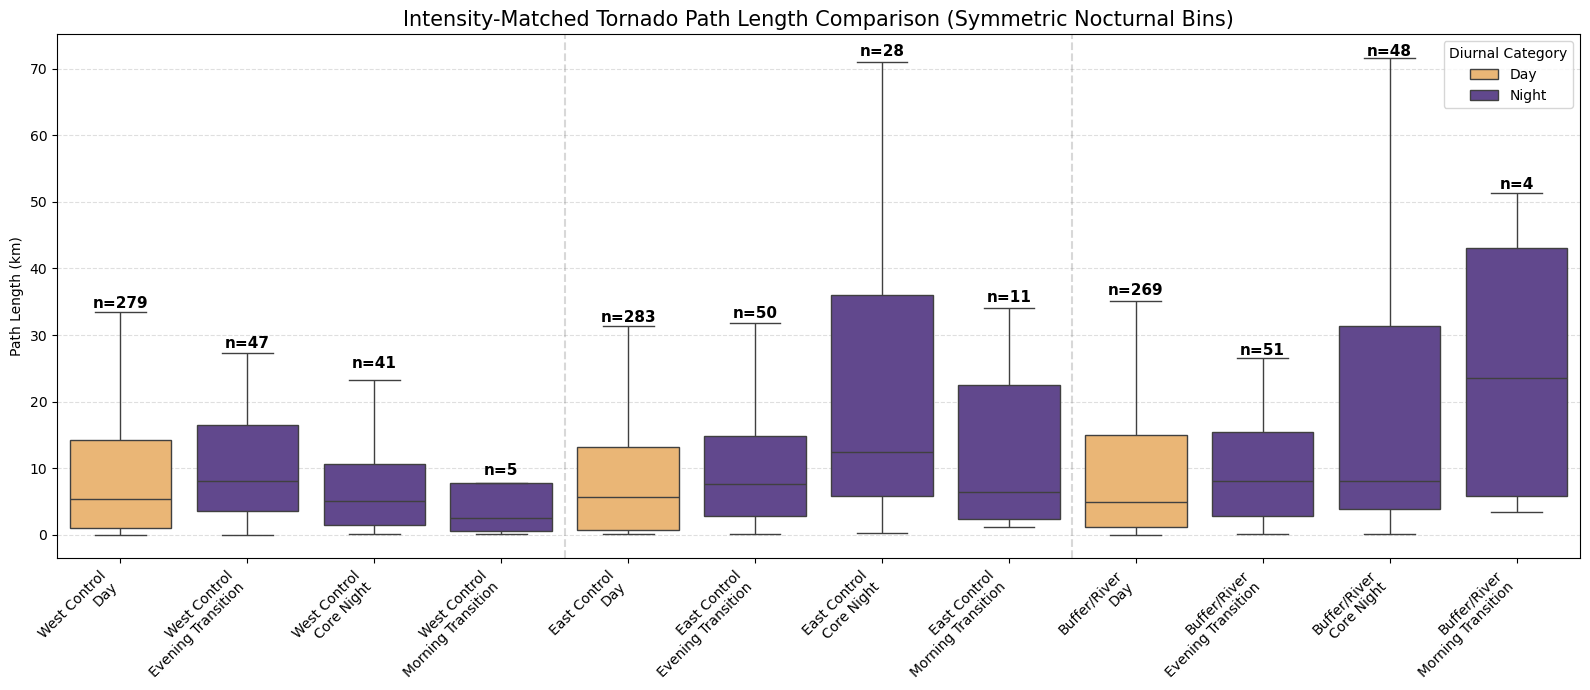


Five-number summary (km):

                                      Min        Q1     Median         Q3  \
group        night_subtype                                                  
Buffer/River Core Night          0.160934  3.862416   8.030607  31.349943   
             Day                 0.000000  1.094351   4.828020  14.966862   
             Evening Transition  0.160934  2.816345   8.046700  15.409430   
             Morning Transition  3.363521  5.801671  23.520504  43.142382   
East Control Core Night          0.241401  5.809717  12.375825  35.968749   
             Day                 0.016093  0.692016   5.584410  13.148308   
             Evening Transition  0.160934  2.808298   7.563898  14.842138   
             Morning Transition  1.126538  2.397917   6.437360  22.530760   
West Control Core Night          0.160934  1.480593   5.021141  10.637737   
             Day                 0.000000  0.941464   5.310822  14.146099   
             Evening Transition  0.000000  3.596

In [57]:
# ================================================================
# Prepare bins (SYMMETRIC VERSION)
# ================================================================

valid_bins = ["Day", "Evening Transition", "Core Night", "Morning Transition"]

df_compare = df_compare[df_compare["night_subtype"].isin(valid_bins)].copy()

df_compare["group_bin"] = df_compare["group"] + "\n" + df_compare["night_subtype"]

# Day vs Night color
df_compare["day_night_simple"] = df_compare["night_subtype"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = [
    "West Control\nDay","West Control\nEvening Transition","West Control\nCore Night","West Control\nMorning Transition",
    "East Control\nDay","East Control\nEvening Transition","East Control\nCore Night","East Control\nMorning Transition",
    "Buffer/River\nDay","Buffer/River\nEvening Transition","Buffer/River\nCore Night","Buffer/River\nMorning Transition"
]

# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(16,7))

ax = sns.boxplot(
    data=df_compare,
    x="group_bin",
    y="len_km",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

ax.set_title("Intensity-Matched Tornado Path Length Comparison (Symmetric Nocturnal Bins)", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Diurnal Category")

plt.xticks(rotation=45, ha="right")

# separators
for x in [3.5, 7.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

# ------------------------------------------------
# Compute counts for each box
# ------------------------------------------------

counts = df_compare.groupby(["group","night_subtype"]).size()

print("\nCounts used in boxplot:\n")
print(counts)

# ------------------------------------------------
# Add count labels (UPDATE POSITIONS AS NEEDED)
# ------------------------------------------------

positions = {

    # WEST CONTROL
    ("West Control","Day"):(0,34),
    ("West Control","Evening Transition"):(1,28),
    ("West Control","Core Night"):(2,25),
    ("West Control","Morning Transition"):(3,9),

    # EAST CONTROL
    ("East Control","Day"):(4,32),
    ("East Control","Evening Transition"):(5,32.5),
    ("East Control","Core Night"):(6,72),
    ("East Control","Morning Transition"):(7,35),

    # BUFFER / RIVER
    ("Buffer/River","Day"):(8,36),
    ("Buffer/River","Evening Transition"):(9,27),
    ("Buffer/River","Core Night"):(10,72),
    ("Buffer/River","Morning Transition"):(11,52),
}

for (grp, period), (x, y) in positions.items():

    n = counts.get((grp, period), 0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary
# ================================================================

summary = (
    df_compare.groupby(["group","night_subtype"])["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (km):\n")
print(summary)

In [58]:
# ================================================================
# Prepare groups for statistical testing (SYMMETRIC BINS)
# ================================================================

valid_bins = ["Day", "Evening Transition", "Core Night", "Morning Transition"]

df_compare = df_compare[df_compare["night_subtype"].isin(valid_bins)].copy()

df_compare["group_bin_full"] = (
    df_compare["group"] + " " + df_compare["night_subtype"]
)

groups = df_compare.groupby("group_bin_full")["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['Buffer/River Core Night', 'Buffer/River Day', 'Buffer/River Evening Transition', 'Buffer/River Morning Transition', 'East Control Core Night', 'East Control Day', 'East Control Evening Transition', 'East Control Morning Transition', 'West Control Core Night', 'West Control Day', 'West Control Evening Transition', 'West Control Morning Transition']


In [59]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")


Kruskal-Wallis Test on Tornado Path Lengths
------------------------------------------------------
H = 29.173
p-value = 0.002134


In [60]:
# ================================================================
# Pairwise Comparisons
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p_val = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Core Night,Buffer/River Day,9.127675,0.002518,Yes
1,Buffer/River Core Night,Buffer/River Evening Transition,1.450375,0.228468,No
2,Buffer/River Core Night,Buffer/River Morning Transition,0.199309,0.655279,No
3,Buffer/River Core Night,East Control Core Night,0.760846,0.383064,No
4,Buffer/River Core Night,East Control Day,9.561187,0.001987,Yes
...,...,...,...,...,...
61,West Control Core Night,West Control Evening Transition,3.280934,0.070089,No
62,West Control Core Night,West Control Morning Transition,0.299314,0.584313,No
63,West Control Day,West Control Evening Transition,2.450748,0.117469,No
64,West Control Day,West Control Morning Transition,0.385698,0.534569,No


In [61]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Core Night,Buffer/River Day,9.127675,0.002518,Yes,0.166169,No
1,Buffer/River Core Night,Buffer/River Evening Transition,1.450375,0.228468,No,15.078869,No
2,Buffer/River Core Night,Buffer/River Morning Transition,0.199309,0.655279,No,43.248401,No
3,Buffer/River Core Night,East Control Core Night,0.760846,0.383064,No,25.282212,No
4,Buffer/River Core Night,East Control Day,9.561187,0.001987,Yes,0.131165,No
...,...,...,...,...,...,...,...
61,West Control Core Night,West Control Evening Transition,3.280934,0.070089,No,4.625877,No
62,West Control Core Night,West Control Morning Transition,0.299314,0.584313,No,38.564650,No
63,West Control Day,West Control Evening Transition,2.450748,0.117469,No,7.752944,No
64,West Control Day,West Control Morning Transition,0.385698,0.534569,No,35.281582,No


In [62]:
# ================================================================
# Extract significant comparisons
# ================================================================

print("\nAll significant comparisons:")
display(pairwise_df[pairwise_df["Significant?"] == "Yes"][[
    "Group1","Group2","H","p-value"
]])

print("\nBonferroni-significant comparisons:")
display(pairwise_df[pairwise_df["Adj Significant?"] == "Yes"][[
    "Group1","Group2","H","p-value","Adj p-value (Bonferroni)"
]])


All significant comparisons:


,Group1,Group2,H,p-value
0,Buffer/River Core Night,Buffer/River Day,9.127675,0.002518
4,Buffer/River Core Night,East Control Day,9.561187,0.001987
7,Buffer/River Core Night,West Control Core Night,7.379242,0.006598
8,Buffer/River Core Night,West Control Day,8.915186,0.002828
13,Buffer/River Day,East Control Core Night,9.509956,0.002044
38,East Control Core Night,East Control Day,10.943249,0.000939
39,East Control Core Night,East Control Evening Transition,4.787716,0.028663
41,East Control Core Night,West Control Core Night,9.864769,0.001685
42,East Control Core Night,West Control Day,10.434465,0.001237



Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


In [63]:
# ================================================================
# Bootstrap testing (SYMMETRIC BINS)
# ================================================================

n_boot = 10000

p_values = []

for i in range(n_boot):

    west_sample = sample_controls_by_intensity(buffer_river, west_control)
    east_sample = sample_controls_by_intensity(buffer_river, east_control)

    df_boot = pd.concat([buffer_river, west_sample, east_sample])

    df_boot = df_boot[df_boot["night_subtype"].isin(valid_bins)]

    df_boot["group_bin_full"] = (
        df_boot["group"] + " " + df_boot["night_subtype"]
    )

    groups_boot = df_boot.groupby("group_bin_full")["len_km"].apply(list)

    try:
        H_boot, p_boot = kruskal(*groups_boot)
        p_values.append(p_boot)
    except:
        continue

# ------------------------------------------------
# Bootstrap Results
# ------------------------------------------------

p_values = np.array(p_values)

print("\nBootstrap Results:")
print("Mean p-value:", np.mean(p_values))
print("Median p-value:", np.median(p_values))
print("Fraction significant (p < 0.05):", np.mean(p_values < 0.05))


Bootstrap Results:
Mean p-value: 0.010967162266875476
Median p-value: 0.0034076941580967837
Fraction significant (p < 0.05): 0.9504


In [64]:
# ================================================================
# Diagnostics (UPDATED)
# ================================================================

print("\nBin counts (Buffer/River):")
print(buffer_river["night_subtype"].value_counts(dropna=False))

print("\nBin counts (West Control):")
print(west_control["night_subtype"].value_counts(dropna=False))

print("\nBin counts (East Control):")
print(east_control["night_subtype"].value_counts(dropna=False))

print("\nMissing values check:")
print(buffer_river["night_subtype"].isna().sum())
print(west_control["night_subtype"].isna().sum())
print(east_control["night_subtype"].isna().sum())

print("\nCSV used:")
print(tornado_csv)


Bin counts (Buffer/River):
night_subtype
Day                   269
Evening Transition     51
Core Night             48
Morning Transition      4
Name: count, dtype: int64

Bin counts (West Control):
night_subtype
Day                   2589
Evening Transition     532
Core Night             352
Morning Transition      81
Name: count, dtype: int64

Bin counts (East Control):
night_subtype
Day                   1445
Evening Transition     276
Core Night             100
Morning Transition      46
Name: count, dtype: int64

Missing values check:
0
0
0

CSV used:
/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times_and_nocturnal_bins.csv


### Tornado Path Lengths by Symmetric Nocturnal Phases

A Kruskal–Wallis test was conducted to evaluate differences in tornado path lengths across **12 groups**, representing Buffer/River, West Control, and East Control populations subdivided into **Day, Evening Transition, Core Night, and Morning Transition** periods.

The test indicated a statistically significant difference among groups:

- **H = 29.173**  
- **p = 0.0021**

This suggests that at least one population exhibits significantly different path length characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests identified several statistically significant differences at the **α = 0.05 level**. Notable comparisons include:

- **Buffer/River Core Night vs Buffer/River Day** (H = 9.13, p = 0.0025)  
- **Buffer/River Core Night vs East Control Day** (H = 9.56, p = 0.0020)  
- **Buffer/River Core Night vs West Control Day** (H = 8.92, p = 0.0028)  
- **East Control Core Night vs East Control Day** (H = 10.94, p = 0.0009)  
- **East Control Core Night vs West Control Day** (H = 10.43, p = 0.0012)

These results suggest that **core nocturnal tornadoes**, particularly within the Buffer/River and East Control groups, tend to exhibit longer path lengths compared to daytime tornadoes.

However, after applying a **Bonferroni correction (66 comparisons)**:

- **No pairwise comparisons remained statistically significant**

This reflects the conservative nature of the correction and indicates that individual differences are sensitive to multiple testing.

### Distributional Insights

The five-number summaries show:

- **Buffer/River tornadoes** exhibit notably higher median path lengths during:
  - **Core Night (~8.0 km)**  
  - **Morning Transition (~23.5 km, highest median overall)**  

- **East Control Core Night** also shows elevated median path lengths (~12.4 km), exceeding both its daytime and transition counterparts.

- **West Control tornadoes** exhibit generally shorter path lengths across all bins, particularly during **Morning Transition (~2.6 km median)**.

### Bootstrap Robustness

To assess statistical stability, **10,000 bootstrap iterations** were performed with intensity-matched sampling:

- **Mean p-value:** 0.011  
- **Median p-value:** 0.0034  
- **Fraction significant (p < 0.05): 95.0%**

This indicates that the overall group differences are **robust and consistently detected**, even though individual pairwise comparisons are not significant after strict correction.

### Interpretation

Overall, these results suggest that:

- **Nocturnal environments—particularly Core Night and Morning Transition—are associated with longer tornado path lengths**, especially in the Buffer/River and East Control populations.
- The **Morning Transition bin**, despite smaller sample size, exhibits some of the **largest median path lengths**, hinting at potentially favorable environmental conditions (e.g., residual shear, boundary layer evolution).
- While **Bonferroni correction removes pairwise significance**, the strong and consistent bootstrap signal supports a **real, albeit subtle, physical effect**.

These findings reinforce the hypothesis that **nocturnal boundary layer processes modulate tornado persistence**, though the strength of this signal depends on both sampling and statistical framework.

In [65]:
# ================================================================
# Prepare Buffer/River vs Controls (Intensity-Matched)
# TORNADO WIDTH VERSION (yards -> meters)
# ================================================================

np.random.seed(42)

# Combine Buffer/River population
buffer_river = pd.concat([west_side, east_side, crossing_tornadoes]).copy()
buffer_river["group"] = "Buffer/River"

# Assign control labels
west_control["group"] = "West Control"
east_control["group"] = "East Control"

# ================================================================
# Convert tornado width from yards to meters
# ================================================================

for df in [buffer_river, west_control, east_control]:

    df["width_m"] = pd.to_numeric(df["wid"], errors="coerce") * 0.9144

# Remove missing widths
buffer_river = buffer_river.dropna(subset=["width_m"])
west_control = west_control.dropna(subset=["width_m"])
east_control = east_control.dropna(subset=["width_m"])

# ------------------------------------------------
# Function: intensity-matched sampling
# ------------------------------------------------

def sample_controls_by_intensity(buffer_df, control_df):

    samples = []

    for mag in sorted(buffer_df["mag"].dropna().unique()):

        n = (buffer_df["mag"] == mag).sum()

        control_subset = control_df[control_df["mag"] == mag]

        if len(control_subset) == 0:
            continue

        if len(control_subset) >= n:
            sampled = control_subset.sample(
                n=n,
                replace=False,
                random_state=42
            )
        else:
            # fallback: allow replacement if needed
            sampled = control_subset.sample(
                n=n,
                replace=True,
                random_state=42
            )

        samples.append(sampled)

    return pd.concat(samples)

# ------------------------------------------------
# Apply sampling
# ------------------------------------------------

west_sample = sample_controls_by_intensity(buffer_river, west_control)
east_sample = sample_controls_by_intensity(buffer_river, east_control)

# Combine final dataset
df_compare = pd.concat(
    [buffer_river, west_sample, east_sample],
    ignore_index=True
)

print("\nCounts by group:")
print(df_compare["group"].value_counts())

print("\nCounts by EF-scale:")
print(df_compare.groupby(["group","mag"]).size())



Counts by group:
group
Buffer/River    372
West Control    372
East Control    372
Name: count, dtype: int64

Counts by EF-scale:
group         mag
Buffer/River  0      124
              1      122
              2       79
              3       37
              4       10
East Control  0      124
              1      122
              2       79
              3       37
              4       10
West Control  0      124
              1      122
              2       79
              3       37
              4       10
dtype: int64



Counts used in boxplot:

group         night_subtype     
Buffer/River  Core Night             48
              Day                   269
              Evening Transition     51
              Morning Transition      4
East Control  Core Night             20
              Day                   284
              Evening Transition     55
              Morning Transition     13
West Control  Core Night             35
              Day                   279
              Evening Transition     50
              Morning Transition      8
dtype: int64


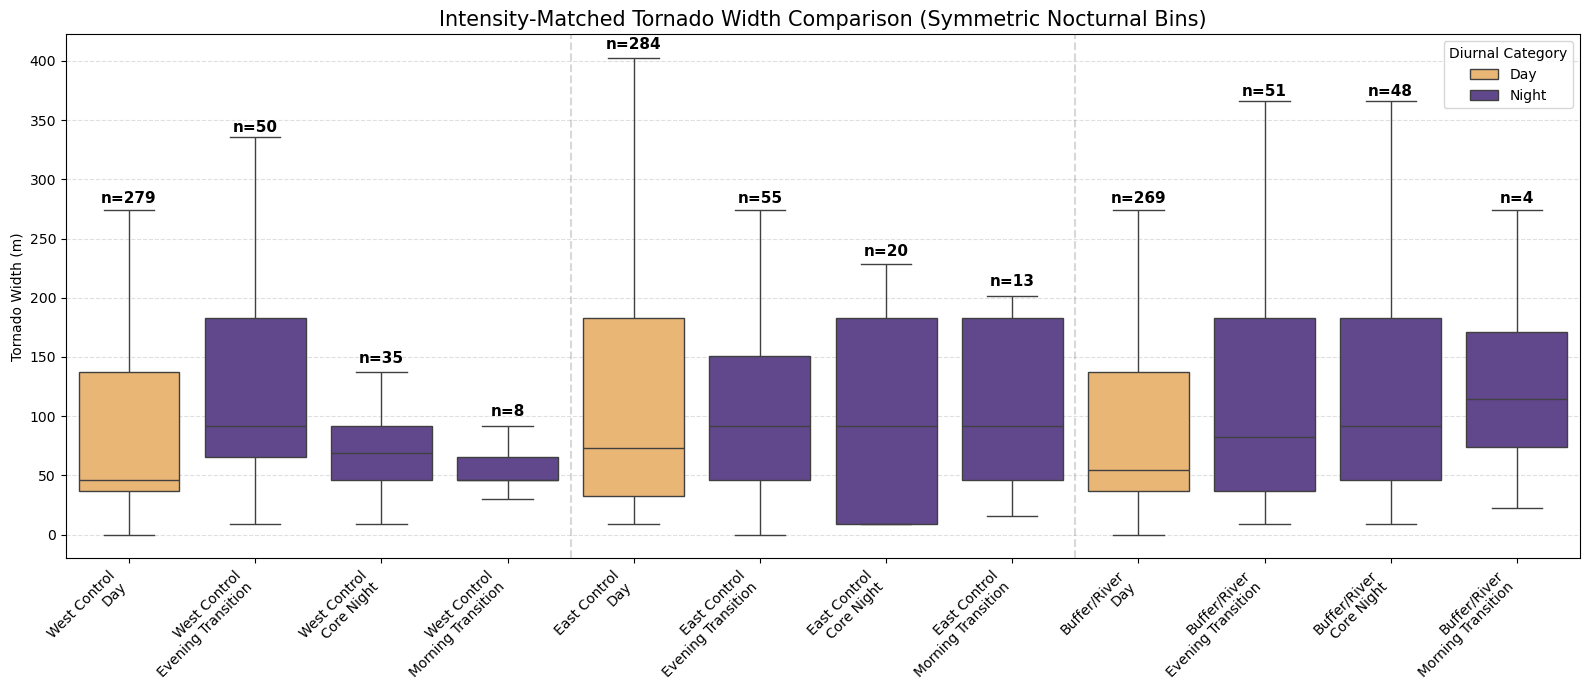


Five-number summary (meters):

                                     Min       Q1   Median        Q3       Max
group        night_subtype                                                    
Buffer/River Core Night           9.1440  45.7200   91.440  182.8800   914.400
             Day                  0.0000  36.5760   54.864  137.1600  2011.680
             Evening Transition   9.1440  36.5760   82.296  182.8800  1005.840
             Morning Transition  22.8600  74.2950  114.300  171.4500   274.320
East Control Core Night           9.1440   9.1440   91.440  182.8800   822.960
             Day                  9.1440  32.9184   73.152  182.8800  1609.344
             Evening Transition   0.0000  45.7200   91.440  150.8760  1188.720
             Morning Transition  15.5448  45.7200   91.440  182.8800   201.168
West Control Core Night           9.1440  45.7200   68.580   91.4400   640.080
             Day                  0.0000  36.5760   45.720  137.1600  2377.440
             Evening

In [66]:
# ================================================================
# Prepare bins (SYMMETRIC VERSION)
# ================================================================

valid_bins = [
    "Day",
    "Evening Transition",
    "Core Night",
    "Morning Transition"
]

df_compare = df_compare[
    df_compare["night_subtype"].isin(valid_bins)
].copy()

df_compare["group_bin"] = (
    df_compare["group"] + "\n" + df_compare["night_subtype"]
)

# Day vs Night color
df_compare["day_night_simple"] = df_compare["night_subtype"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

order = [
    "West Control\nDay",
    "West Control\nEvening Transition",
    "West Control\nCore Night",
    "West Control\nMorning Transition",

    "East Control\nDay",
    "East Control\nEvening Transition",
    "East Control\nCore Night",
    "East Control\nMorning Transition",

    "Buffer/River\nDay",
    "Buffer/River\nEvening Transition",
    "Buffer/River\nCore Night",
    "Buffer/River\nMorning Transition"
]

# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(16,7))

ax = sns.boxplot(
    data=df_compare,
    x="group_bin",
    y="width_m",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Intensity-Matched Tornado Width Comparison "
    "(Symmetric Nocturnal Bins)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Tornado Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clean legend
handles, labels = ax.get_legend_handles_labels()

by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Diurnal Category"
)

plt.xticks(rotation=45, ha="right")

# separators
for x in [3.5, 7.5]:

    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

# ------------------------------------------------
# Compute counts for each box
# ------------------------------------------------

counts = df_compare.groupby(
    ["group","night_subtype"],
    observed=False
).size()

print("\nCounts used in boxplot:\n")
print(counts)

# ------------------------------------------------
# Add count labels
# ------------------------------------------------

positions = {

    # WEST CONTROL
    ("West Control","Day"):(0,280),
    ("West Control","Evening Transition"):(1,340),
    ("West Control","Core Night"):(2,145),
    ("West Control","Morning Transition"):(3,100),

    # EAST CONTROL
    ("East Control","Day"):(4,410),
    ("East Control","Evening Transition"):(5,280),
    ("East Control","Core Night"):(6,235),
    ("East Control","Morning Transition"):(7,210),

    # BUFFER / RIVER
    ("Buffer/River","Day"):(8,280),
    ("Buffer/River","Evening Transition"):(9,370),
    ("Buffer/River","Core Night"):(10,370),
    ("Buffer/River","Morning Transition"):(11,280),
}

for (grp, period), (x, y) in positions.items():

    n = counts.get((grp, period), 0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary
# ================================================================

summary = (
    df_compare
    .groupby(["group","night_subtype"])["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (meters):\n")
print(summary)


In [67]:
# ================================================================
# Prepare groups for statistical testing
# ================================================================

df_compare["group_bin_full"] = (
    df_compare["group"] + " " + df_compare["night_subtype"]
)

groups = (
    df_compare
    .groupby("group_bin_full")["width_m"]
    .apply(list)
)

print("Groups included in analysis:")
print(groups.index.tolist())


Groups included in analysis:
['Buffer/River Core Night', 'Buffer/River Day', 'Buffer/River Evening Transition', 'Buffer/River Morning Transition', 'East Control Core Night', 'East Control Day', 'East Control Evening Transition', 'East Control Morning Transition', 'West Control Core Night', 'West Control Day', 'West Control Evening Transition', 'West Control Morning Transition']


In [68]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal
import itertools

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Widths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print(
        "Interpretation: At least one group differs significantly."
    )
else:
    print(
        "Interpretation: No statistically significant "
        "differences detected."
    )



Kruskal-Wallis Test on Tornado Widths
------------------------------------------------------
H = 14.494
p-value = 0.206829
Interpretation: No statistically significant differences detected.


In [69]:
# ================================================================
# Pairwise Comparisons
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p_val = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)



Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Core Night,Buffer/River Day,2.869230,0.090288,No
1,Buffer/River Core Night,Buffer/River Evening Transition,0.199710,0.654955,No
2,Buffer/River Core Night,Buffer/River Morning Transition,0.024224,0.876316,No
3,Buffer/River Core Night,East Control Core Night,0.661953,0.415871,No
4,Buffer/River Core Night,East Control Day,1.065003,0.302077,No
...,...,...,...,...,...
61,West Control Core Night,West Control Evening Transition,4.667442,0.030740,Yes
62,West Control Core Night,West Control Morning Transition,1.636444,0.200814,No
63,West Control Day,West Control Evening Transition,10.162351,0.001433,Yes
64,West Control Day,West Control Morning Transition,0.218607,0.640103,No


In [70]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = (
    pairwise_df["p-value"] * n_tests
)

pairwise_df["Adj Significant?"] = (
    pairwise_df["Adj p-value (Bonferroni)"]
    .apply(lambda x: "Yes" if x < 0.05 else "No")
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)



Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Core Night,Buffer/River Day,2.869230,0.090288,No,5.959010,No
1,Buffer/River Core Night,Buffer/River Evening Transition,0.199710,0.654955,No,43.227058,No
2,Buffer/River Core Night,Buffer/River Morning Transition,0.024224,0.876316,No,57.836866,No
3,Buffer/River Core Night,East Control Core Night,0.661953,0.415871,No,27.447512,No
4,Buffer/River Core Night,East Control Day,1.065003,0.302077,No,19.937073,No
...,...,...,...,...,...,...,...
61,West Control Core Night,West Control Evening Transition,4.667442,0.030740,Yes,2.028818,No
62,West Control Core Night,West Control Morning Transition,1.636444,0.200814,No,13.253725,No
63,West Control Day,West Control Evening Transition,10.162351,0.001433,Yes,0.094603,No
64,West Control Day,West Control Morning Transition,0.218607,0.640103,No,42.246818,No


In [71]:
# ================================================================
# Extract significant comparisons
# ================================================================

print("\nAll significant comparisons:")

display(
    pairwise_df[pairwise_df["Significant?"] == "Yes"][[
        "Group1",
        "Group2",
        "H",
        "p-value"
    ]]
)

print("\nBonferroni-significant comparisons:")

display(
    pairwise_df[pairwise_df["Adj Significant?"] == "Yes"][[
        "Group1",
        "Group2",
        "H",
        "p-value",
        "Adj p-value (Bonferroni)"
    ]]
)


All significant comparisons:


,Group1,Group2,H,p-value
19,Buffer/River Day,West Control Evening Transition,9.969219,0.001592
49,East Control Day,West Control Evening Transition,4.826878,0.028019
61,West Control Core Night,West Control Evening Transition,4.667442,0.030740
63,West Control Day,West Control Evening Transition,10.162351,0.001433
65,West Control Evening Transition,West Control Morning Transition,5.998566,0.014318



Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


In [72]:
# ================================================================
# Bootstrap testing (SYMMETRIC BINS)
# ================================================================

n_boot = 10000

p_values = []

for i in range(n_boot):

    west_sample = sample_controls_by_intensity(
        buffer_river,
        west_control
    )

    east_sample = sample_controls_by_intensity(
        buffer_river,
        east_control
    )

    df_boot = pd.concat([
        buffer_river,
        west_sample,
        east_sample
    ])

    df_boot = df_boot[
        df_boot["night_subtype"].isin(valid_bins)
    ]

    df_boot["group_bin_full"] = (
        df_boot["group"] + " " + df_boot["night_subtype"]
    )

    groups_boot = (
        df_boot.groupby("group_bin_full")["width_m"]
        .apply(list)
    )

    try:

        H_boot, p_boot = kruskal(*groups_boot)

        p_values.append(p_boot)

    except:
        continue

# ------------------------------------------------
# Bootstrap Results
# ------------------------------------------------

p_values = np.array(p_values)

print("\nBootstrap Results:")
print("Mean p-value:", np.mean(p_values))
print("Median p-value:", np.median(p_values))
print(
    "Fraction significant (p < 0.05):",
    np.mean(p_values < 0.05)
)



Bootstrap Results:
Mean p-value: 0.20682868737441032
Median p-value: 0.20682868737441035
Fraction significant (p < 0.05): 0.0


In [73]:
# ================================================================
# Diagnostics
# ================================================================

print("\nBin counts (Buffer/River):")
print(buffer_river["night_subtype"].value_counts(dropna=False))

print("\nBin counts (West Control):")
print(west_control["night_subtype"].value_counts(dropna=False))

print("\nBin counts (East Control):")
print(east_control["night_subtype"].value_counts(dropna=False))

print("\nMissing values check:")

print(buffer_river["night_subtype"].isna().sum())
print(west_control["night_subtype"].isna().sum())
print(east_control["night_subtype"].isna().sum())

print("\nCSV used:")
print(tornado_csv)


Bin counts (Buffer/River):
night_subtype
Day                   269
Evening Transition     51
Core Night             48
Morning Transition      4
Name: count, dtype: int64

Bin counts (West Control):
night_subtype
Day                   2589
Evening Transition     532
Core Night             352
Morning Transition      81
Name: count, dtype: int64

Bin counts (East Control):
night_subtype
Day                   1445
Evening Transition     276
Core Night             100
Morning Transition      46
Name: count, dtype: int64

Missing values check:
0
0
0

CSV used:
/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times_and_nocturnal_bins.csv


### Tornado Widths by Symmetric Nocturnal Phases

A Kruskal–Wallis test was conducted to evaluate differences in tornado widths across **12 groups**, representing Buffer/River, West Control, and East Control populations subdivided into **Day, Evening Transition, Core Night, and Morning Transition** periods.

The test did **not** indicate a statistically significant difference among groups:

- **H = 14.494**  
- **p = 0.2068**

This suggests that overall tornado width distributions do not differ significantly across the symmetric nocturnal phase framework.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests identified a small number of statistically significant differences at the **α = 0.05 level**. Notable comparisons include:

- **Buffer/River Day vs West Control Evening Transition**  
  (H = 9.97, p = 0.0016)

- **West Control Day vs West Control Evening Transition**  
  (H = 10.16, p = 0.0014)

- **West Control Evening Transition vs West Control Morning Transition**  
  (H = 6.00, p = 0.0143)

- **East Control Day vs West Control Evening Transition**  
  (H = 4.83, p = 0.0280)

- **West Control Core Night vs West Control Evening Transition**  
  (H = 4.67, p = 0.0307)

These differences primarily involve the **West Control Evening Transition population**, suggesting modest variability in tornado widths during transitional nocturnal periods.

However, after applying a **Bonferroni correction (66 comparisons)**:

- **No pairwise comparisons remained statistically significant**

This indicates that the nominally significant pairwise differences are not robust under strict multiple-testing correction.

### Distributional Insights

The five-number summaries show several subtle patterns:

- **Buffer/River tornadoes** exhibit somewhat larger median widths during:
  - **Morning Transition (~114 m median)**  
  - **Core Night (~91 m median)**  
  compared to **Day (~55 m median)**

- **East Control tornadoes** display relatively consistent median widths across nocturnal phases, generally centered near **91 m**.

- **West Control tornadoes** exhibit:
  - Smaller median widths during **Day (~46 m)** and **Morning Transition (~46 m)**  
  - Larger widths during the **Evening Transition (~91 m median)**

- Maximum widths remain highly variable across all populations, with several groups exceeding **800–2000 m**, indicating substantial spread and skewness in tornado width distributions.

### Bootstrap Robustness

To assess statistical stability, **10,000 bootstrap iterations** were performed using intensity-matched resampling:

- **Mean p-value:** 0.2068  
- **Median p-value:** 0.2068  
- **Fraction significant (p < 0.05): 0.0%**

Unlike the tornado path length analyses, the bootstrap results provide **no evidence of a stable or reproducible statistical signal** in tornado width across nocturnal phases.

### Interpretation

Overall, these results suggest that:

- **Tornado width is considerably less sensitive to nocturnal phase and river interaction than tornado path length**.
- Although a few nominal pairwise differences emerge, particularly involving the **West Control Evening Transition population**, these differences are weak and not statistically robust after correction for multiple testing.
- The absence of significant bootstrap support further indicates that observed differences are likely driven by sampling variability rather than a persistent physical signal.

Importantly, while previous analyses demonstrated stronger nocturnal effects for **tornado persistence and path length**, the present results imply that **tornado width may be governed more strongly by storm-scale dynamics and intensity variability than by nocturnal boundary layer evolution or river interaction**.

Overall, the symmetric nocturnal phase framework does not provide strong evidence that tornado widths systematically vary as a function of river interaction or nocturnal timing.